In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 129.4 KB


In [6]:
df.shape

(1340, 10)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [10]:
df.dropna(inplace=True)
df.shape

(1332, 10)

In [11]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000
mean,674.474474,38.086336,30.658333,94.189189,1.099850,13325.246426
std,384.703785,11.112804,6.118967,11.445173,1.205958,12109.620712
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,341.750000,29.000000,26.200000,86.000000,0.000000,4760.157500
50%,674.500000,38.000000,30.350000,92.000000,1.000000,9412.965000
75%,1007.250000,47.000000,34.725000,99.000000,2.000000,16781.327500
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [15]:
# Select numeric columns (integers and floats)
numeric_cols = df.select_dtypes(include=['number'])
# Select categorical columns (strings, object types, or category types)
categorical_cols = df.select_dtypes(include=['str', 'category'])

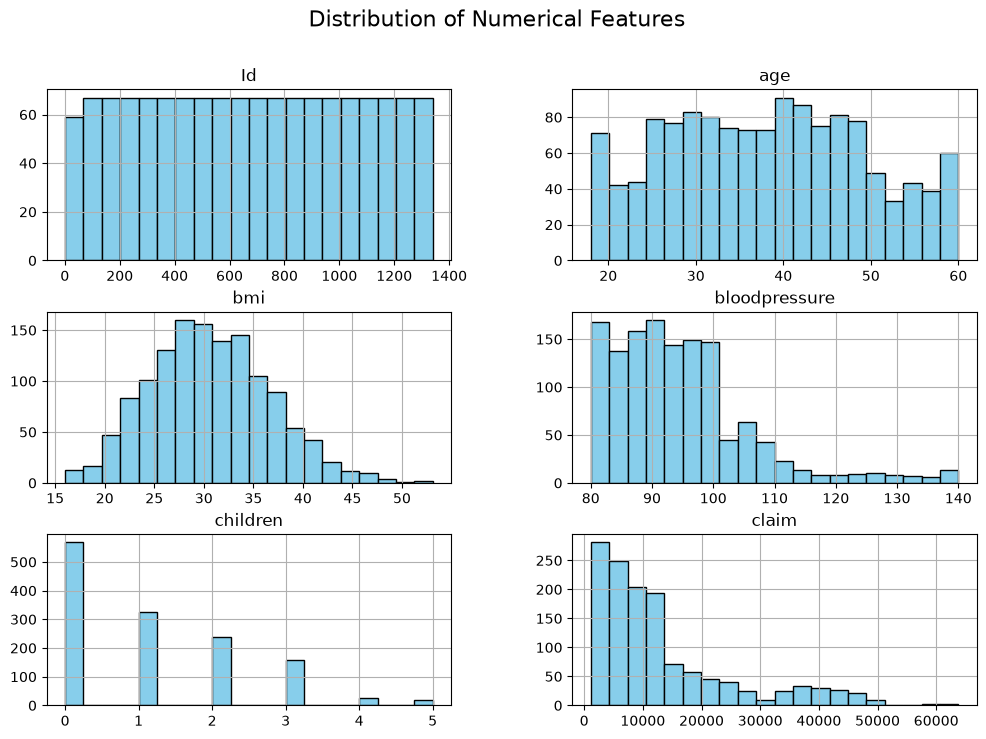

In [28]:
numeric_cols.hist(bins=20, figsize=(12, 8), color="skyblue", edgecolor="black")

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

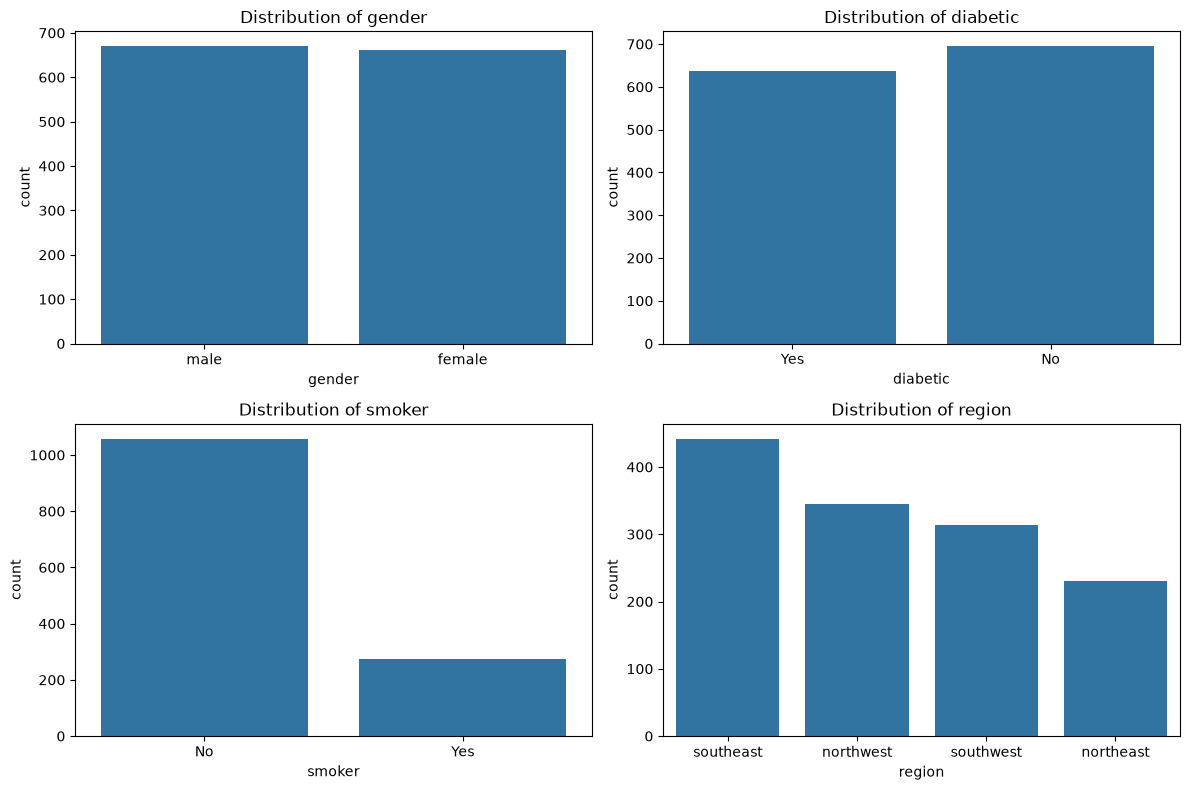

In [30]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    # Pass the column series straight to x, don't use data=
    sns.countplot(x=categorical_cols[col])
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [31]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No         8762.30
        Yes       30679.00
male    No         8169.25
        Yes       33042.01
Name: claim, dtype: float64

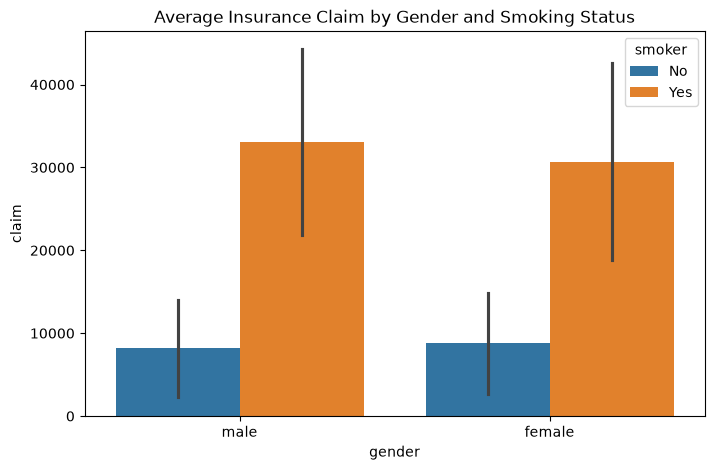

In [33]:
plt.figure(figsize=(8, 5))

# Use the direct barplot function
sns.barplot(
    data=df, 
    x="gender", 
    y="claim", 
    hue="smoker", 
    estimator="mean", 
    errorbar="sd"
)

plt.title("Average Insurance Claim by Gender and Smoking Status")
plt.show()


In [37]:
region_diabetic = df.groupby(["region","diabetic"])["claim"].mean().unstack()

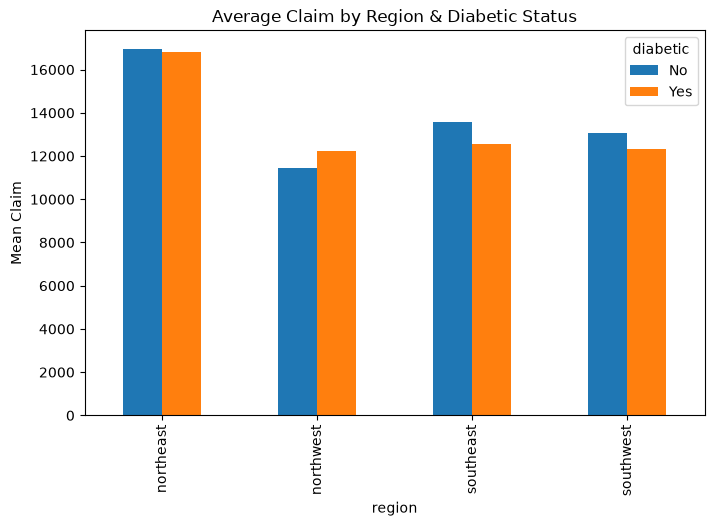

In [38]:
region_diabetic.plot(kind="bar",figsize=(8,5))
plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()

In [46]:
pivot_table = pd.pivot_table(df,values="claim",index="region",columns="smoker",aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,8076.203415,30192.002759
southeast,7444.144872,34844.997253
southwest,8294.754102,32269.064138


In [45]:
pivot_table = pd.pivot_table(df,values="claim",index="children",columns="diabetic",aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.395398,11985.289857
1,12730.455810,12732.055724
2,15567.767583,14579.360417
3,13807.612892,17091.258649
4,14106.630000,13573.352500
5,8519.043636,9205.594286


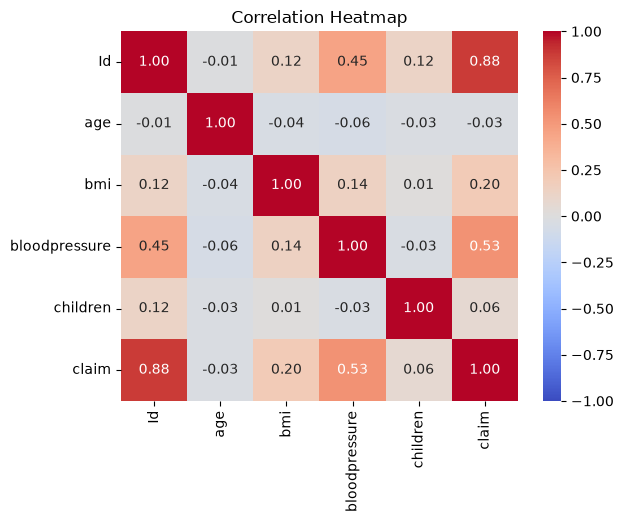

In [42]:
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Heatmap")
plt.show()